In [ ]:
import os
import shutil

# Make sure the .kaggle folder exists
os.makedirs("/root/.kaggle", exist_ok=True)

# Move kaggle.json from /content to /root/.kaggle
shutil.move("/content/kaggle.json", "/root/.kaggle/kaggle.json")

# Set correct permissions
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API configured successfully!")


Kaggle API configured successfully!


In [ ]:
!pip install kaggle
!kaggle datasets download -d gunavenkatdoddi/eye-diseases-classification

Dataset URL: https://www.kaggle.com/datasets/gunavenkatdoddi/eye-diseases-classification
License(s): ODbL-1.0
 97% 711M/736M [00:02<00:00, 267MB/s]
100% 736M/736M [00:02<00:00, 364MB/s]


In [ ]:
!unzip -q eye-diseases-classification.zip -d /content/eye_diseases_dataset

In [ ]:
# ============================================================
# Eye Disease Classification Training Script
# ============================================================

!pip install timm albumentations==1.4.0 torchmetrics

import os, glob, random, time
import numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
import timm
import torch
from torch import nn, optim
from torch.cuda.amp import GradScaler, autocast
from torchmetrics.classification import MulticlassF1Score
from PIL import Image

# ============================================================
# CONFIG
# ============================================================
data_dir = "/content/eye_diseases_dataset/dataset"
num_epochs = 30
batch_size = 32
img_size = 384
lr = 3e-4
weight_decay = 1e-2
device = "cuda" if torch.cuda.is_available() else "cpu"
num_workers = 2
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# ============================================================
# DATASET & TRANSFORMS
# ============================================================
train_tfms = A.Compose([
    A.RandomResizedCrop(img_size, img_size, scale=(0.8, 1.0)),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.2),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussNoise(p=0.2),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=20, p=0.5),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_tfms = A.Compose([
    A.Resize(img_size, img_size),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

class EyeDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        image = np.array(Image.open(img_path).convert("RGB"))
        if self.transform:
            image = self.transform(image=image)["image"]
        return image, label

# ============================================================
# DATA PREPARATION
# ============================================================
classes = sorted(os.listdir(data_dir))
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
print("Classes:", class_to_idx)

image_paths, labels = [], []
for cls in classes:
    files = glob.glob(os.path.join(data_dir, cls, "*"))
    image_paths.extend(files)
    labels.extend([class_to_idx[cls]] * len(files))

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths, labels, test_size=0.15, stratify=labels, random_state=seed
)

train_ds = EyeDiseaseDataset(train_paths, train_labels, train_tfms)
val_ds = EyeDiseaseDataset(val_paths, val_labels, val_tfms)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False,
                        num_workers=num_workers, pin_memory=True)

# ============================================================
# MODEL
# ============================================================
num_classes = len(classes)
model = timm.create_model("efficientnet_b3", pretrained=True, num_classes=num_classes)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
scaler = GradScaler()

# ============================================================
# TRAINING LOOP
# ============================================================
best_f1 = 0.0

for epoch in range(1, num_epochs + 1):
    model.train()
    train_loss = 0.0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{num_epochs} [Train]"):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.item()

    scheduler.step()

    # Validation
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{num_epochs} [Val]"):
            images = images.to(device)
            outputs = model(images)
            pred = torch.argmax(outputs, 1).cpu().numpy()
            preds.extend(pred)
            gts.extend(labels.numpy())

    f1 = f1_score(gts, preds, average="macro")
    print(f"Epoch {epoch}: Train Loss={train_loss/len(train_loader):.4f}  Val F1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save(model.state_dict(), "best_model.pth")
        print("✅ Best model saved (Val F1 improved)")

print("Training complete! Best macro-F1:", best_f1)


Classes: {'cataract': 0, 'diabetic_retinopathy': 1, 'glaucoma': 2, 'normal': 3}


/tmp/ipython-input-1491492531.py:112: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/30 [Train]:   0%|          | 0/112 [00:00<?, ?it/s]/tmp/ipython-input-1491492531.py:125: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/30 [Val]: 100%|██████████| 20/20 [00:08<00:00,  2.36it/s]


Epoch 1: Train Loss=0.7608  Val F1=0.8831
✅ Best model saved (Val F1 improved)


Epoch 2/30 [Train]:   0%|          | 0/112 [00:00<?, ?it/s]/tmp/ipython-input-1491492531.py:125: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 2/30 [Val]: 100%|██████████| 20/20 [00:08<00:00,  2.35it/s]


Epoch 2: Train Loss=0.3229  Val F1=0.9178
✅ Best model saved (Val F1 improved)


...

Epoch 28: Train Loss=0.0105  Val F1=0.9534


Epoch 29/30 [Train]:   0%|          | 0/112 [00:00<?, ?it/s]/tmp/ipython-input-1491492531.py:125: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 29/30 [Val]: 100%|██████████| 20/20 [00:07<00:00,  2.61it/s]


Epoch 29: Train Loss=0.0112  Val F1=0.9534


Epoch 30/30 [Train]:   0%|          | 0/112 [00:00<?, ?it/s]/tmp/ipython-input-1491492531.py:125: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 30/30 [Val]: 100%|██████████| 20/20 [00:08<00:00,  2.40it/s]

Epoch 30: Train Loss=0.0126  Val F1=0.9534
Training complete! Best macro-F1: 0.9614455698110529


In [ ]:
!pip install -U timm


In [ ]:
model = timm.create_model("efficientnet_b3", pretrained=True, num_classes=num_classes)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

                      precision    recall  f1-score   support

            cataract       0.98      0.98      0.98       156
diabetic_retinopathy       0.99      1.00      1.00       165
            glaucoma       0.95      0.88      0.91       151
              normal       0.89      0.95      0.92       161

            accuracy                           0.95       633
           macro avg       0.95      0.95      0.95       633
        weighted avg       0.95      0.95      0.95       633



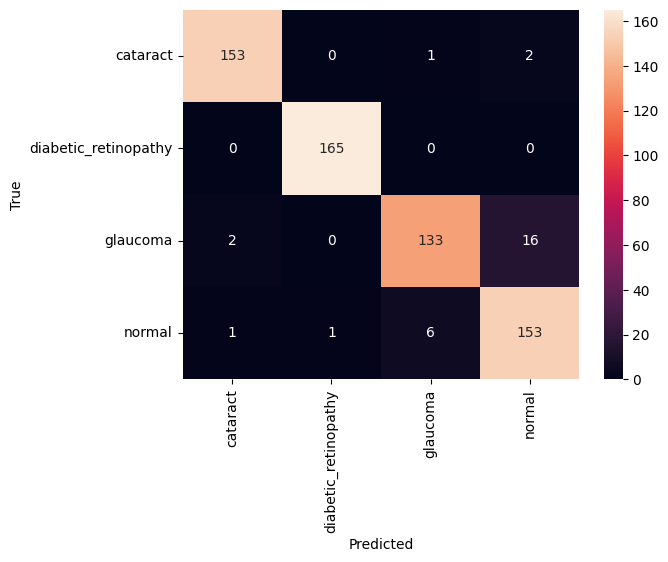

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(gts, preds, target_names=classes))
sns.heatmap(confusion_matrix(gts, preds), annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()


In [ ]:
!pip install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44284 sha256=f0f51784fdf4ec9edb217cc661511569cb5bff0eeb798ccc7cffa63791c12c52
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


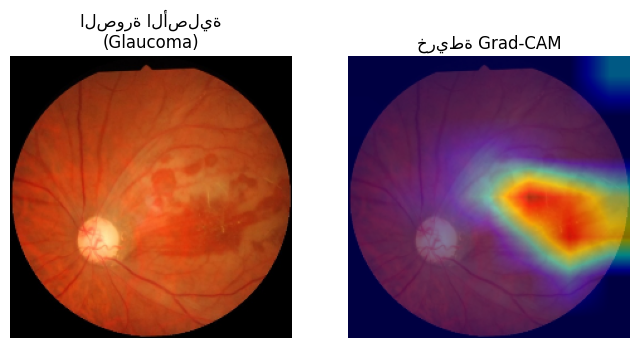

In [ ]:

# ==========================================================
# 🔹 استيراد المكتبات
# ==========================================================
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image

# ==========================================================
# 🔹 تحميل النموذج المدرب
# ==========================================================
model.load_state_dict(torch.load("best_model.pth", map_location=device))
model.eval()

# ==========================================================
# 🔹 تحديد الطبقة المستهدفة (آخر طبقة convolution عادة)
# ==========================================================
target_layer = model.blocks[-1][-1].conv_pw
# ==========================================================
# 🔹 إنشاء كائن Grad-CAM (بدون use_cuda)
# ==========================================================
cam = GradCAM(model=model, target_layers=[target_layer])

# ==========================================================
# 🔹 دالة لعرض خريطة Grad-CAM لصورة واحدة
# ==========================================================
def visualize_gradcam(img_path, true_label=None):
    img = cv2.imread(img_path)
    if img is None:
        print(f"❌ لم يتم العثور على الصورة في المسار: {img_path}")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))
    rgb_img = np.float32(img) / 255.0

    # تجهيز الصورة
    input_tensor = preprocess_image(rgb_img, mean=[0.485, 0.456, 0.406],
                                    std=[0.229, 0.224, 0.225]).to(device)

    # ✅ بدون unsqueeze
    grayscale_cam = cam(input_tensor=input_tensor)[0, :]

    # دمج الخريطة مع الصورة الأصلية
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # عرض النتيجة
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title(f"الصورة الأصلية\n({true_label})" if true_label else "Original")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title("خريطة Grad-CAM")
    plt.axis('off')
    plt.show()

# ==========================================================
# 🔹 دالة لعرض صورة عشوائية من كل فئة (اختياري)
# ==========================================================
def visualize_gradcam_from_all_classes(base_dir, class_names):
    plt.figure(figsize=(12, 8))
    i = 1
    for cls in class_names:
        folder = os.path.join(base_dir, cls)
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        if not files:
            continue
        img_path = os.path.join(folder, np.random.choice(files))
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (224, 224))
        rgb_img = np.float32(img) / 255.0
        input_tensor = preprocess_image(rgb_img, mean=[0.485, 0.456, 0.406],
                                        std=[0.229, 0.224, 0.225]).to(device)
        grayscale_cam = cam(input_tensor=input_tensor)[0, :]
        visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

        plt.subplot(2, 4, i)
        plt.imshow(rgb_img)
        plt.title(f"{cls}\nOriginal")
        plt.axis('off')

        plt.subplot(2, 4, i+4)
        plt.imshow(visualization)
        plt.title("Grad-CAM")
        plt.axis('off')
        i += 1
    plt.tight_layout()
    plt.show()

# ==========================================================
# 🔹 مثال: عرض خريطة لصورة واحدة
# ==========================================================
visualize_gradcam("/content/eye_diseases_dataset/dataset/glaucoma/1020_left.jpg", "Glaucoma")


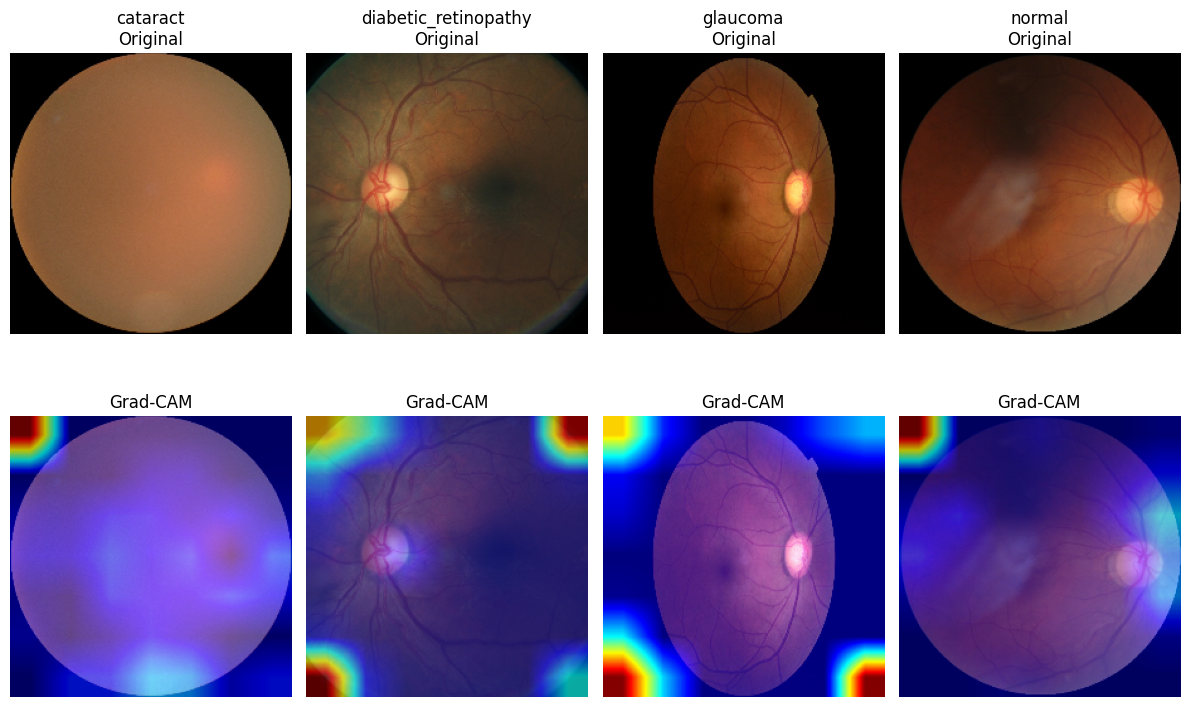

In [ ]:
# ==========================================================
# 🔹 مثال: عرض صورة عشوائية من كل فئة
# ==========================================================
class_names = ["cataract", "diabetic_retinopathy", "glaucoma", "normal"]
visualize_gradcam_from_all_classes("/content/eye_diseases_dataset/dataset", class_names)

# **Testing**

In [ ]:
import torch
import timm
from torchvision import transforms
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image
import numpy as np

# ============================================================
# CONFIG
# ============================================================
model_path = "best_model.pth"
data_dir = "/content/eye_diseases_dataset/dataset"  # same as before
img_size = 384
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load classes (same order as training)
classes = sorted(os.listdir(data_dir))
num_classes = len(classes)

# ============================================================
# LOAD MODEL
# ============================================================
model = timm.create_model("efficientnet_b3", pretrained=False, num_classes=num_classes)
model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()
print("✅ Model loaded successfully!")


✅ Model loaded successfully!


In [ ]:
# Albumentations transform (same as validation)
val_tfms = A.Compose([
    A.Resize(img_size, img_size),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

def predict_image(image_path):
    image = np.array(Image.open(image_path).convert("RGB"))
    image = val_tfms(image=image)["image"].unsqueeze(0).to(device)
    with torch.no_grad():
        outputs = model(image)
        pred = torch.argmax(outputs, 1).item()
    return classes[pred]

# Example usage:
img_path = "/content/1083_left_cataract.jpg"
pred_class = predict_image(img_path)
print("Predicted Class:", pred_class)


Predicted Class: cataract


In [ ]:
img_path = "/content/10003_right_diabetic.jpeg"
pred_class = predict_image(img_path)
print("Predicted Class:", pred_class)

Predicted Class: diabetic_retinopathy


In [ ]:
img_path = "/content/1214_right_glaucoma.jpg"
pred_class = predict_image(img_path)
print("Predicted Class:", pred_class)

Predicted Class: glaucoma


In [ ]:
img_path = "/content/1060_left._normal.jpg"
pred_class = predict_image(img_path)
print("Predicted Class:", pred_class)

Predicted Class: normal


In [ ]:
img_path = "/content/10029_left.jpeg"
pred_class = predict_image(img_path)
print("Predicted Class:", pred_class)

Predicted Class: diabetic_retinopathy
